<a href="https://colab.research.google.com/github/dilaraogz/REINFORCEMENT_LEARN-NG/blob/main/Dilarao%C4%9FuzRL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

In [13]:
# Grid boyutu
GRID_SIZE = 6

# 5 farklı lokasyon
LOCATIONS = [(0,0), (0,5), (5,0), (5,5), (3,3)]

# State ve action sayısı
NUM_STATES = GRID_SIZE * GRID_SIZE * (len(LOCATIONS)+1) * len(LOCATIONS)
NUM_ACTIONS = 6

# Hareket yönleri
ACTIONS = {
    0: (-1, 0),  # yukarı
    1: (1, 0),   # aşağı
    2: (0, -1),  # sol
    3: (0, 1),   # sağ
}

In [15]:
def encode(row, col, pass_loc, dest):
    i = row
    i = i * GRID_SIZE + col
    i = i * (len(LOCATIONS)+1) + pass_loc
    i = i * len(LOCATIONS) + dest
    return i

def decode(i):
    dest = i % len(LOCATIONS)
    i //= len(LOCATIONS)

    pass_loc = i % (len(LOCATIONS)+1)
    i //= (len(LOCATIONS)+1)

    col = i % GRID_SIZE
    i //= GRID_SIZE

    row = i
    return row, col, pass_loc, dest

In [16]:
class TaxiEnv:
    def __init__(self):
        self.state = None

    def reset(self):
        row = random.randint(0, GRID_SIZE-1)
        col = random.randint(0, GRID_SIZE-1)
        pass_loc = random.randint(0, len(LOCATIONS)-1)
        dest = random.randint(0, len(LOCATIONS)-1)

        while dest == pass_loc:
            dest = random.randint(0, len(LOCATIONS)-1)

        self.state = encode(row, col, pass_loc, dest)
        return self.state

    def step(self, action):
        row, col, pass_loc, dest = decode(self.state)
        reward = -1

        if action in ACTIONS:
            dr, dc = ACTIONS[action]
            row = max(0, min(GRID_SIZE-1, row + dr))
            col = max(0, min(GRID_SIZE-1, col + dc))

        elif action == 4:  # pickup
            if pass_loc < len(LOCATIONS) and (row, col) == LOCATIONS[pass_loc]:
                pass_loc = len(LOCATIONS)
            else:
                reward = -10

        elif action == 5:  # dropoff
            if pass_loc == len(LOCATIONS) and (row, col) == LOCATIONS[dest]:
                reward = 20
                self.state = encode(row, col, pass_loc, dest)
                return self.state, reward, True
            else:
                reward = -10

        self.state = encode(row, col, pass_loc, dest)
        return self.state, reward, False

    def render(self):
        row, col, pass_loc, dest = decode(self.state)

        grid = [["." for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]

        for i, (r,c) in enumerate(LOCATIONS):
            grid[r][c] = str(i)

        grid[row][col] = "T"

        for r in grid:
            print(" ".join(r))
        print()

In [17]:
env = TaxiEnv()

q_table = np.zeros((NUM_STATES, NUM_ACTIONS))

alpha = 0.1
gamma = 0.6
epsilon = 1.0

min_epsilon = 0.01
decay = 0.995

episodes = 5000
rewards = []

for ep in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:

        # keşif vs öğrenilen
        if random.uniform(0,1) < epsilon:
            action = random.randint(0,5)
        else:
            action = np.argmax(q_table[state])

        next_state, reward, done = env.step(action)

        # Q update
        q_table[state, action] = (1-alpha)*q_table[state, action] + \
            alpha*(reward + gamma*np.max(q_table[next_state]))

        state = next_state
        total_reward += reward

    # epsilon azaltma
    epsilon = max(min_epsilon, epsilon * decay)

    rewards.append(total_reward)

    if ep % 500 == 0:
        print("Episode:", ep)

Episode: 0
Episode: 500
Episode: 1000
Episode: 1500
Episode: 2000
Episode: 2500
Episode: 3000
Episode: 3500
Episode: 4000
Episode: 4500


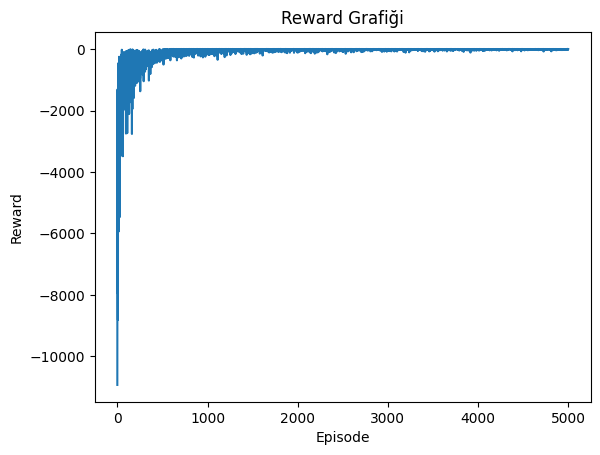

In [18]:
plt.plot(rewards)
plt.title("Reward Grafiği")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

In [19]:
def run_agent(env, q_table):
    frames = []

    state = env.reset()
    done = False

    while not done:
        action = np.argmax(q_table[state])
        next_state, reward, done = env.step(action)

        frames.append({
            "state": env.state,
            "reward": reward,
            "action": action
        })

        state = next_state

    return frames

In [20]:
def show_frames(frames, env):
    for i, frame in enumerate(frames):
        clear_output(wait=True)

        env.state = frame["state"]
        env.render()

        print(f"Adım: {i+1}")
        print(f"Aksiyon: {frame['action']}")
        print(f"Reward: {frame['reward']}")

        time.sleep(0.5)

In [21]:
frames = run_agent(env, q_table)
show_frames(frames, env)

0 . . . . T
. . . . . .
. . . . . .
. . . 4 . .
. . . . . .
2 . . . . 3

Adım: 10
Aksiyon: 5
Reward: 20
